# Cell counts

In [2]:
# import needed libraries
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import scanpy as sc
from matplotlib import rc_file_defaults
from statannot import add_stat_annotation 
from statannotations.Annotator import Annotator # for statistical annotations in plots

from sklearn import preprocessing
import sys
sys.path.append('../../../phenotyping')
from phenotyping_utils import generate_anndata_from_cell_table

import logging
logger = logging.getLogger()

In [3]:
adata = generate_anndata_from_cell_table(cell_table_path='../../../CellTable_CleanCohort/updated_cell_table_Ki67.csv', biosamples_path='../../../CellTable_CleanCohort/CleanCohort_Metadata.csv')

/Users/linus/opt/miniconda3/envs/imc_analysis/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [4]:
adata.obs['Pixie'].replace('B cell', 'Unassigned', inplace=True)
adata.obs['Pixie'].replace('Macrophage', 'Macrophage M1', inplace=True)
adata.obs['Pixie'].replace('Monocyte', 'NonCl Monocyte', inplace=True)
adata = adata[adata.obs['Pixie']!='Unassigned']

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_43444/1236980481.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs['Pixie'].replace('B cell', 'Unassigned', inplace=True)
/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_43444/1236980481.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead

In [18]:
# pretreat = adata[adata.obs['Sample_Type_(pre/post treatment)']=='pre'].copy()
pretreat = adata[adata.obs['Response']=='Non-Responder'].copy() ###use this line when analysing Non-Responders

In [19]:
# study = 'Response'
study = 'Sample_Type_(pre/post treatment)' ###use this line when analysing Non-Responders

# Create the first dataframe
cell_counts = pd.DataFrame()

# Generate the second dataframe
# Group by Image ID, Response, and Cell Label and count the cells
cell_counts = pretreat.obs.groupby(['acquisition_ID', 'Pixie']).size().unstack(fill_value=0)

# Reset the index to make Image ID and Response columns
cell_counts = cell_counts.reset_index()

# Add the Response column (assuming the response is the same for all cells in an image)
response_mapping = pretreat.obs.drop_duplicates(subset=['acquisition_ID'])[['acquisition_ID', study]]
cell_counts = cell_counts.merge(response_mapping, on='acquisition_ID', how='left')

# Display the final dataframe
cell_counts

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_43444/3107232010.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = pretreat.obs.groupby(['acquisition_ID', 'Pixie']).size().unstack(fill_value=0)


,acquisition_ID,Antigen presenting cell,B cell + HLA,B7H4 Cancer cell,B7H4 Cancer cell Prol,CD8 T cell,Cancer cell,Cancer cell Prol,Cl Monocyte,Endothelial cell,...,Macrophage M1,Macrophage + HLA,Macrophage M2,Memory CD4 T cell,Memory CD8 T cell,NonCl Monocyte,NK/CD8,Neutrophil,Regulatory T cell,Sample_Type_(pre/post treatment)
0,Leap001_10,37,0,64,19,1251,591,227,6,70,...,171,21,8,55,210,25,41,138,1,pre
1,Leap001_8,119,0,193,35,3497,1347,384,1,306,...,593,59,6,70,507,39,121,50,10,pre
2,Leap001_9,23,0,98,19,1687,888,209,2,149,...,187,33,3,29,401,6,69,36,2,pre
3,Leap002_1,111,7,160,21,4550,1078,160,5,257,...,323,22,22,41,185,45,82,82,7,post
4,Leap002_3,149,1,75,4,2530,401,53,11,121,...,156,17,14,82,26,39,100,1,3,post
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,Leap096_5,244,9,764,162,403,3611,1274,3,179,...,333,92,24,128,151,3,266,2,15,post
330,Leap096_6,419,9,747,205,617,2321,1006,5,235,...,585,31,14,337,27,11,339,3,22,post
331,Leap096_7,406,6,672,155,805,1931,931,1,325,...,402,27,3,339,13,6,268,3,33,post
332,Leap096_8,326,3,405,57,1382,1963,590,4,1264,...,240,22,35,135,223,4,66,3,7,post


In [20]:
#Normalise

# Create the first dataframe
#df = pd.DataFrame(data)

cell_counts_norm = pd.DataFrame()

# Generate the second dataframe
# Group by Image ID, Response, and Cell Label and count the cells
cell_counts_norm = pretreat.obs.groupby(['acquisition_ID', 'Pixie']).size().unstack(fill_value=0)

# Reset the index to make Image ID and Response columns
cell_counts_norm = cell_counts_norm.reset_index()

# Add a column with the total number of cells per image
cell_counts_norm['Total Cells'] = cell_counts_norm.iloc[:, 1:].sum(axis=1)

# Add the Response column (assuming the response is the same for all cells in an image)
response_mapping = pretreat.obs.drop_duplicates(subset=['acquisition_ID'])[['acquisition_ID', study]]
cell_counts_norm = cell_counts_norm.merge(response_mapping, on='acquisition_ID', how='left')

# Normalize the cell counts by dividing by the total number of cells per image
for column in cell_counts_norm.columns[1:-2]:  # Exclude 'Image ID', 'Response', and 'Total Cells'
    cell_counts_norm[column] = cell_counts_norm[column] / cell_counts_norm['Total Cells']

# Display the final dataframe
cell_counts_norm

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_43444/2051111115.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts_norm = pretreat.obs.groupby(['acquisition_ID', 'Pixie']).size().unstack(fill_value=0)


,acquisition_ID,Antigen presenting cell,B cell + HLA,B7H4 Cancer cell,B7H4 Cancer cell Prol,CD8 T cell,Cancer cell,Cancer cell Prol,Cl Monocyte,Endothelial cell,...,Macrophage + HLA,Macrophage M2,Memory CD4 T cell,Memory CD8 T cell,NonCl Monocyte,NK/CD8,Neutrophil,Regulatory T cell,Total Cells,Sample_Type_(pre/post treatment)
0,Leap001_10,0.011768,0.000000,0.020356,0.006043,0.397901,0.187977,0.072201,0.001908,0.022265,...,0.006679,0.002545,0.017494,0.066794,0.007952,0.013041,0.043893,0.000318,3144,pre
1,Leap001_8,0.015061,0.000000,0.024427,0.004430,0.442602,0.170485,0.048601,0.000127,0.038729,...,0.007467,0.000759,0.008860,0.064169,0.004936,0.015315,0.006328,0.001266,7901,pre
2,Leap001_9,0.005530,0.000000,0.023563,0.004568,0.405626,0.213513,0.050252,0.000481,0.035826,...,0.007935,0.000721,0.006973,0.096417,0.001443,0.016591,0.008656,0.000481,4159,pre
3,Leap002_1,0.015216,0.000960,0.021933,0.002879,0.623715,0.147772,0.021933,0.000685,0.035230,...,0.003016,0.003016,0.005620,0.025360,0.006169,0.011241,0.011241,0.000960,7295,post
4,Leap002_3,0.035637,0.000239,0.017938,0.000957,0.605118,0.095910,0.012676,0.002631,0.028940,...,0.004066,0.003348,0.019613,0.006219,0.009328,0.023918,0.000239,0.000718,4181,post
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,Leap096_5,0.030360,0.001120,0.095060,0.020157,0.050143,0.449297,0.158517,0.000373,0.022272,...,0.011447,0.002986,0.015926,0.018788,0.000373,0.033097,0.000249,0.001866,8037,post
330,Leap096_6,0.058001,0.001246,0.103405,0.028378,0.085410,0.321290,0.139258,0.000692,0.032530,...,0.004291,0.001938,0.046650,0.003738,0.001523,0.046927,0.000415,0.003045,7224,post
331,Leap096_7,0.060363,0.000892,0.099911,0.023045,0.119685,0.287095,0.138418,0.000149,0.048320,...,0.004014,0.000446,0.050401,0.001933,0.000892,0.039845,0.000446,0.004906,6726,post
332,Leap096_8,0.046974,0.000432,0.058357,0.008213,0.199135,0.282853,0.085014,0.000576,0.182133,...,0.003170,0.005043,0.019452,0.032133,0.000576,0.009510,0.000432,0.001009,6940,post


In [21]:
#Dataframe in which I merge together the pro-tumour agents and the anti-tumour agents
antiprotumour=cell_counts.copy()
antiprotumour

# Add a column with the total number of cells per image
antiprotumour['Total Cells'] = antiprotumour.iloc[:, 1:-1].sum(axis=1)
antiprotumour["Pro-Tumour Agents"] = antiprotumour.apply(lambda row: (row['Regulatory T cell'] + row['B7H4 Cancer cell'] + row['Macrophage M2'])/row['Total Cells'], axis=1)

counts=antiprotumour.copy()

# Normalize the cell counts by dividing by the total number of cells per image
for column in antiprotumour.columns[1:-3]:  # Exclude 'Image ID', 'Response', and 'Total Cells'
    antiprotumour[column] = antiprotumour[column] / antiprotumour['Total Cells']

antiprotumour

,acquisition_ID,Antigen presenting cell,B cell + HLA,B7H4 Cancer cell,B7H4 Cancer cell Prol,CD8 T cell,Cancer cell,Cancer cell Prol,Cl Monocyte,Endothelial cell,...,Macrophage M2,Memory CD4 T cell,Memory CD8 T cell,NonCl Monocyte,NK/CD8,Neutrophil,Regulatory T cell,Sample_Type_(pre/post treatment),Total Cells,Pro-Tumour Agents
0,Leap001_10,0.011768,0.000000,0.020356,0.006043,0.397901,0.187977,0.072201,0.001908,0.022265,...,0.002545,0.017494,0.066794,0.007952,0.013041,0.043893,0.000318,pre,3144,0.023219
1,Leap001_8,0.015061,0.000000,0.024427,0.004430,0.442602,0.170485,0.048601,0.000127,0.038729,...,0.000759,0.008860,0.064169,0.004936,0.015315,0.006328,0.001266,pre,7901,0.026452
2,Leap001_9,0.005530,0.000000,0.023563,0.004568,0.405626,0.213513,0.050252,0.000481,0.035826,...,0.000721,0.006973,0.096417,0.001443,0.016591,0.008656,0.000481,pre,4159,0.024766
3,Leap002_1,0.015216,0.000960,0.021933,0.002879,0.623715,0.147772,0.021933,0.000685,0.035230,...,0.003016,0.005620,0.025360,0.006169,0.011241,0.011241,0.000960,post,7295,0.025908
4,Leap002_3,0.035637,0.000239,0.017938,0.000957,0.605118,0.095910,0.012676,0.002631,0.028940,...,0.003348,0.019613,0.006219,0.009328,0.023918,0.000239,0.000718,post,4181,0.022004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,Leap096_5,0.030360,0.001120,0.095060,0.020157,0.050143,0.449297,0.158517,0.000373,0.022272,...,0.002986,0.015926,0.018788,0.000373,0.033097,0.000249,0.001866,post,8037,0.099913
330,Leap096_6,0.058001,0.001246,0.103405,0.028378,0.085410,0.321290,0.139258,0.000692,0.032530,...,0.001938,0.046650,0.003738,0.001523,0.046927,0.000415,0.003045,post,7224,0.108389
331,Leap096_7,0.060363,0.000892,0.099911,0.023045,0.119685,0.287095,0.138418,0.000149,0.048320,...,0.000446,0.050401,0.001933,0.000892,0.039845,0.000446,0.004906,post,6726,0.105263
332,Leap096_8,0.046974,0.000432,0.058357,0.008213,0.199135,0.282853,0.085014,0.000576,0.182133,...,0.005043,0.019452,0.032133,0.000576,0.009510,0.000432,0.001009,post,6940,0.064409


In [22]:
data = antiprotumour

# Create the dataframe
df = pd.DataFrame(data)

# Transform the dataframe to the desired format
transformed_df = df.melt(
    id_vars=['acquisition_ID', study, 'Total Cells'], 
    #id_vars=['acquisition_ID', 'Response', 'Total Cells'], 
    var_name='Cell Type', 
    value_name='Mean'
)

# Display the transformed dataframe
transformed_df

,acquisition_ID,Sample_Type_(pre/post treatment),Total Cells,Cell Type,Mean
0,Leap001_10,pre,3144,Antigen presenting cell,0.011768
1,Leap001_8,pre,7901,Antigen presenting cell,0.015061
2,Leap001_9,pre,4159,Antigen presenting cell,0.005530
3,Leap002_1,post,7295,Antigen presenting cell,0.015216
4,Leap002_3,post,4181,Antigen presenting cell,0.035637
...,...,...,...,...,...
7009,Leap096_5,post,8037,Pro-Tumour Agents,0.099913
7010,Leap096_6,post,7224,Pro-Tumour Agents,0.108389
7011,Leap096_7,post,6726,Pro-Tumour Agents,0.105263
7012,Leap096_8,post,6940,Pro-Tumour Agents,0.064409


In [23]:
# Specific Comparisons for the statistics

unique_treatments = transformed_df['Cell Type'].unique()
unique_areas = transformed_df[study].unique()

comparison_pairs = []

# Comparisons Between Areas for the Same Treatment
for treatment in unique_treatments:
    area_pairs = [(area1, area2) for i, area1 in enumerate(unique_areas) for area2 in unique_areas[i+1:]]
    for area1, area2 in area_pairs:
        pair = ((treatment, area1), (treatment, area2))
        if pair not in comparison_pairs:
            comparison_pairs.append(pair)

# Print added specific comparisons
print(f"Specific Comparisons: {comparison_pairs}")


Specific Comparisons: [(('Antigen presenting cell', 'pre'), ('Antigen presenting cell', 'post')), (('B cell + HLA', 'pre'), ('B cell + HLA', 'post')), (('B7H4 Cancer cell', 'pre'), ('B7H4 Cancer cell', 'post')), (('B7H4 Cancer cell Prol', 'pre'), ('B7H4 Cancer cell Prol', 'post')), (('CD8 T cell', 'pre'), ('CD8 T cell', 'post')), (('Cancer cell', 'pre'), ('Cancer cell', 'post')), (('Cancer cell Prol', 'pre'), ('Cancer cell Prol', 'post')), (('Cl Monocyte', 'pre'), ('Cl Monocyte', 'post')), (('Endothelial cell', 'pre'), ('Endothelial cell', 'post')), (('Fibroblast', 'pre'), ('Fibroblast', 'post')), (('Int Monocyte', 'pre'), ('Int Monocyte', 'post')), (('Macrophage M1', 'pre'), ('Macrophage M1', 'post')), (('Macrophage + HLA', 'pre'), ('Macrophage + HLA', 'post')), (('Macrophage M2', 'pre'), ('Macrophage M2', 'post')), (('Memory CD4 T cell', 'pre'), ('Memory CD4 T cell', 'post')), (('Memory CD8 T cell', 'pre'), ('Memory CD8 T cell', 'post')), (('NonCl Monocyte', 'pre'), ('NonCl Monocyte'

In [25]:
PhenoNorm = ['Antigen presenting cell', 'B cell + HLA', 'B7H4 Cancer cell', 'B7H4 Cancer cell Prol',
             'CD8 T cell', 'Cancer cell', 'Cancer cell Prol', 'Cl Monocyte', 'Endothelial cell',
             'Fibroblast', 'Int Monocyte', 'Macrophage M1', 'Macrophage + HLA', 'Macrophage M2',
             'Memory CD4 T cell', 'Memory CD8 T cell', 'NonCl Monocyte', 'NK/CD8', 'Neutrophil',
             'Regulatory T cell', 'Pro-Tumour Agents']

PhenoNormMean = ['Antigen presenting cell Median', 'B cell + HLA Median', 'B7H4 Cancer cell Median',
                 'B7H4 Cancer cell Prol Median', 'CD8 T cell Median', 'Cancer cell Median',
                 'Cancer cell Prol Median', 'Cl Monocyte Median','Endothelial cell Median',
                 'Fibroblast Median', 'Int Monocyte Median', 'Macrophage M1 Median',
                 'Macrophage + HLA Median', 'Macrophage M2 Median', 'Memory CD4 T cell Median',
                 'Memory CD8 T cell Median', 'NonCl Monocyte Median', 'NK/CD8 Median',
                 'Neutrophil Median', 'Regulatory T cell Median', 'Pro-Tumour Agents Median']

PhenoNormSEM = ['Antigen presenting cell SEM', 'B cell + HLA SEM', 'B7H4 Cancer cell SEM',
                'B7H4 Cancer cell Prol SEM', 'CD8 T cell SEM', 'Cancer cell SEM',
                'Cancer cell Prol SEM', 'Cl Monocyte SEM', 'Endothelial cell SEM',
                'Fibroblast SEM', 'Int Monocyte SEM', 'Macrophage M1 SEM', 'Macrophage + HLA SEM',
                'Macrophage M2 SEM', 'Memory CD4 T cell SEM', 'Memory CD8 T cell SEM',
                'NonCl Monocyte SEM', 'NK/CD8 SEM', 'Neutrophil SEM', 'Regulatory T cell SEM',
                'Pro-Tumour Agents SEM']

In [26]:
df=antiprotumour

df2 = df.groupby([study])[PhenoNorm[0]].agg(
    mean='median', sem=lambda x: np.std(x, ddof=1) / np.sqrt(len(x))
    ).reset_index()

# Calculate the mean and standard error for each group
for i in range(1, len(PhenoNorm)):
    temp=df.groupby([study])[PhenoNorm[i]].agg(
    mean='median', sem=lambda x: np.std(x, ddof=1) / np.sqrt(len(x))
    ).reset_index()

    df2[PhenoNormMean[i]] = temp['mean']
    df2[PhenoNormSEM[i]] = temp['sem']

df2.rename(columns={'mean': 'Antigen presenting cell Median'}, inplace = True)
df2.rename(columns={'sem': 'Antigen presenting cell SEM'}, inplace = True)

df2


,Sample_Type_(pre/post treatment),Antigen presenting cell Median,Antigen presenting cell SEM,B cell + HLA Median,B cell + HLA SEM,B7H4 Cancer cell Median,B7H4 Cancer cell SEM,B7H4 Cancer cell Prol Median,B7H4 Cancer cell Prol SEM,CD8 T cell Median,...,NonCl Monocyte Median,NonCl Monocyte SEM,NK/CD8 Median,NK/CD8 SEM,Neutrophil Median,Neutrophil SEM,Regulatory T cell Median,Regulatory T cell SEM,Pro-Tumour Agents Median,Pro-Tumour Agents SEM
0,post,0.041543,0.002806,0.000488,0.000130,0.040615,0.003131,0.011932,0.002306,0.176101,...,0.001523,0.000975,0.031873,0.003095,0.002897,0.001384,0.002456,0.000322,0.047787,0.003082
1,pre,0.050000,0.003505,0.000313,0.000123,0.042477,0.003161,0.017391,0.002485,0.166804,...,0.001998,0.000452,0.021667,0.001598,0.003005,0.002087,0.003216,0.000426,0.050637,0.003104


In [27]:
from scipy.stats import shapiro, levene

In [28]:
df = antiprotumour
for i in range(0, len(PhenoNorm)):

    cell = PhenoNorm[i]
    print(cell)
    
    # Arrays for saving unique pairs and p-values
    comparison_pairs2 = []
    comparison_p_values = []
    
    
    # Step 1: Check Normality for Each Group
    print("Step 1: Normality Test (Shapiro-Wilk)")
    normality = df.groupby([study])[cell].apply(shapiro)
    normality_results = {group: pval for group, (_, pval) in normality.items()}
    for group, pval in normality_results.items():
        print(f"Group: {group}, p-value: {pval}")
    print("\n")
    
    # Step 2: Check Variance Homogeneity
    print("Step 2: Variance Homogeneity Test (Levene’s Test)")
    levene_stat, levene_p = levene(*[group[cell].values for _, group in df.groupby([study])])
    print(f"Levene’s Test Statistic: {levene_stat}, p-value: {levene_p}")
    print("\n")
    
    # Step 3: Perform Global Tests and Post-Hoc Analyses
    if all(p > 0.05 for p in normality_results.values()):  # Normal distribution
        print('Normal distribution')
        if levene_p > 0.05:  # Equal variances
            print("Equal variances - Use Two-Way ANOVA")
    
            print("\nand Tukey's HSD Post-Hoc Test")
            
            
        else:
            print("Unequal Variances - Use Welch's ANOVA")
    
    else:
        print("Use Kruskal-Wallis (non-parametric)")
    
        print("\nand perform Dunn's post-hoc test with some multiple testing correction")

Antigen presenting cell
Step 1: Normality Test (Shapiro-Wilk)
Group: post, p-value: 1.723457075697529e-13
Group: pre, p-value: 1.4066457273856135e-09


Step 2: Variance Homogeneity Test (Levene’s Test)
Levene’s Test Statistic: 6.62755516934433, p-value: 0.010474207223657179


Use Kruskal-Wallis (non-parametric)

and perform Dunn's post-hoc test with some multiple testing correction
B cell + HLA
Step 1: Normality Test (Shapiro-Wilk)
Group: post, p-value: 3.1482935390804296e-20
Group: pre, p-value: 1.8524427559390146e-19


Step 2: Variance Homogeneity Test (Levene’s Test)
Levene’s Test Statistic: 0.028016200185409998, p-value: 0.8671726467317765


Use Kruskal-Wallis (non-parametric)

and perform Dunn's post-hoc test with some multiple testing correction
B7H4 Cancer cell
Step 1: Normality Test (Shapiro-Wilk)
Group: post, p-value: 8.989044329484969e-08
Group: pre, p-value: 7.528214116640732e-09


Step 2: Variance Homogeneity Test (Levene’s Test)
Levene’s Test Statistic: 0.14711923080847936

In [29]:
############Palette#################
#Responder
T1 ='darkmagenta'# "#008000" #match powerpoint colours
#Non-Responder
T2 = 'gold'#"#8b0000"#match powerpoint colours
#Set Palette
colours = [T2, T1]

#palette
palette = sns.color_palette(colours)
###################################

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Fibroblast_pre vs. Fibroblast_post: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:1.397e-03 Stat=1.021e+01
Macrophage M1_pre vs. Macrophage M1_post: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:1.026e-05 Stat=1.946e+01
Macrophage M2_pre vs. Macrophage M2_post: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:5.438e-07 Stat=2.510e+01
NK/CD8_pre vs. NK/CD8_post: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:7.307e-05 Stat=1.573e+01


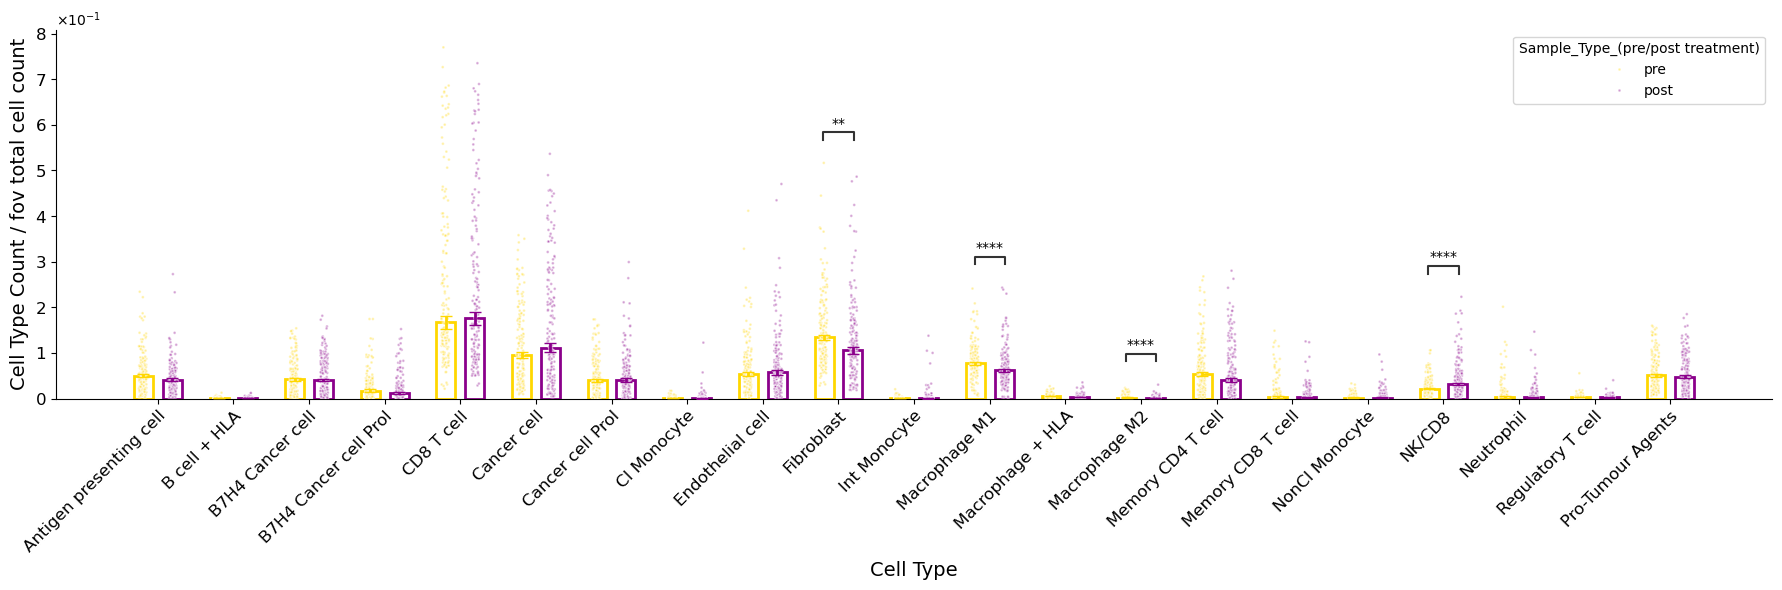

In [30]:
# treatments = ['Non-Responder', 'Responder']
# filename = 'FS4-1A_CellTypes_NonResponders'
treatments = ['pre', 'post'] ###uncomment if analysing Non-Responders
filename = 'FS5-1A_CellTypes_PrePost' ###uncomment if analysing Non-Responders
data_scatter = transformed_df

# Set the bar width and positions for the grouped bars
bar_width = 0.25
index = np.arange(len(PhenoNorm))  # X positions of bars
index_list = list(PhenoNorm)

# Create Bar Plot with ax.bar and Error Bars (Mean ± SEM)
fig, ax = plt.subplots(figsize=(18, 6))

#Loop through each treatment and plot the bars
for i, treatment in enumerate(treatments):
    # Calculate the x positions for each bar
    positions = (index + i * 0.38)-0.19
    #print(positions)
    #print('i ', i, ' treatment ', treatment)
    treatment_data = df2[df2[study] == treatment]#.astype(str) == treatment]

    heights=[]
    errors=[]
    for c in range(0,len(PhenoNorm)):
        heights.append(treatment_data.iloc[0][PhenoNormMean[c]])
        errors.append(treatment_data.iloc[0][PhenoNormSEM[c]])

    ax.bar(
        x = positions,
        height = heights,
        width = bar_width,
        color = 'white',
        edgecolor = palette[i],
        linewidth = 2)
    
    # Add error bars
    ax.errorbar(
        x=positions,
        y=heights,
        yerr=errors,  # Use SEM for error bars
        color=palette[i],  # Error bar color
        capsize=4,
        fmt='none',
        zorder = 10,
        linewidth=2)

sns.stripplot(data=data_scatter,
          ax=ax,
          x='Cell Type',
          y='Mean',
          hue=study,
          dodge=True,
          size=2,
          edgecolor="white",
          linewidth=1,
          palette=palette,
          order = index_list,
          alpha=0.4)


annotator = Annotator(ax, comparison_pairs, data=data_scatter, x='Cell Type', y='Mean', hue=study)#, order=order)
annotator.configure(hide_non_significant=True)
annotator.configure(test='Kruskal', text_format='star', loc='inside', comparisons_correction='benjamini-hochberg')
annotator.apply_and_annotate()

# Customize the plot aesthetics
ax.set_xlabel('Cell Type', fontsize=14)
ax.set_ylabel('Cell Type Count / fov total cell count', fontsize=14)
#ax.set_title(title)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Set x-ticks to be the center of the grouped bars
ax.set_xticks(index - bar_width )
#ax.set_xticklabels(PhenoNorm)
ax.set_xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20], PhenoNorm, rotation=45, rotation_mode="anchor", ha="right")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#ax.set_ylim(0,0.0006)
plt.ylim(ymin=0)

ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useOffset=None, useLocale=None, useMathText=True)

plt.tight_layout()

plt.savefig('../../manuscript/'+filename+'.png',format='png', dpi=600, bbox_inches='tight')

plt.show()


## Ratios

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

pre vs. post: Kruskal-Wallis independent samples (pairwise between groups) with Bonferroni correction, P_val:3.861e-02 Stat=4.278e+00


/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_43444/2773284354.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ratios2,


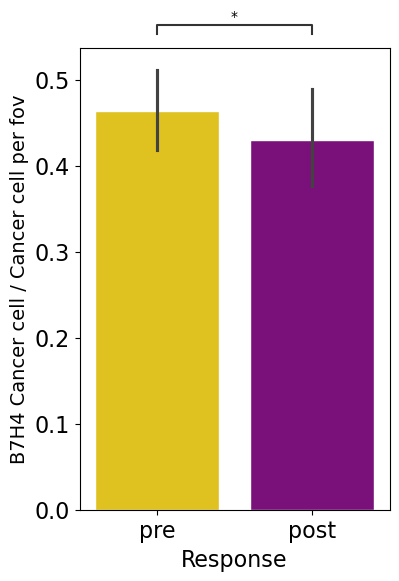

In [32]:
ratios = antiprotumour.copy()

cell1='B7H4 Cancer cell'
cell2='Cancer cell'

ratios2 = ratios[ratios[cell2]>0.0000001].copy()


ratios2["Ratios"] = ratios2.apply(lambda row: (row[cell1]+0.00000000000000000001) / (row[cell2]+0.00000000000000000001), axis=1)

fig, ax3 = plt.subplots(figsize=(4, 6))
sns.barplot(data=ratios2,
          ax=ax3,
          x=study,
          y='Ratios',
          #hue='Response',
          #dodge=True,
          #size=5,
          edgecolor="white",
          linewidth=1,
          palette=palette,
          #order = index_list,
          #alpha=0.2
             )

# Customize the plot aesthetics
ax3.set_xlabel(study, fontsize=16)
ax3.set_ylabel(''+cell1+' / '+cell2+' per fov', fontsize=14)
#ax3.set_ylim(-20,70)
ax3.set_xlabel('Response', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


#[('pre', 'post')], [('Non-Responder', 'Responder')]
annotator = Annotator(ax3, [('pre', 'post')], data=ratios2, x=study, y='Ratios')#, order=order)
#annotator.configure(hide_non_significant=True)
annotator.configure(test='Kruskal', text_format='star', loc='outside', comparisons_correction='bonferroni')
annotator.apply_and_annotate()


#plt.savefig('/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/Figures/New/Ratios_Pre_B7Cancer.png',format='png', dpi=600, bbox_inches='tight')

plt.show()